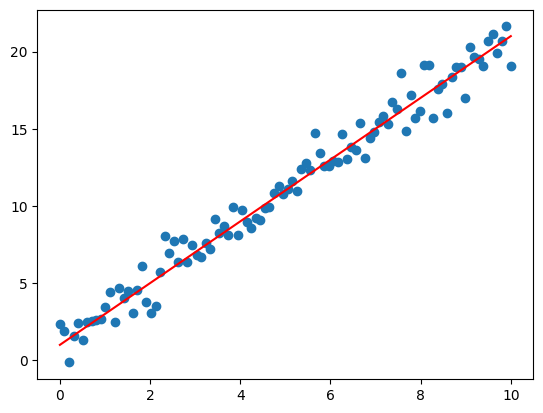

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 2 * X + 1 + np.random.randn(100, 1)

plt.scatter(X, y)
plt.plot(X, 2 * X + 1, color='red')
plt.show()

epoch 0 loss: 156.80730004266042
epoch 100 loss: 0.9770648571227217
epoch 200 loss: 0.9749943211979542
epoch 300 loss: 0.9734576621383862
epoch 400 loss: 0.9723168637176997
epoch 500 loss: 0.97146974208834
epoch 600 loss: 0.9708405757096509
epoch 700 loss: 0.9703732150944513
epoch 800 loss: 0.9700260030755783
epoch 900 loss: 0.9697680226160996


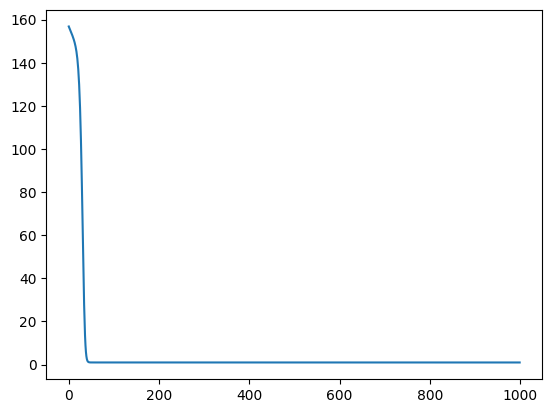

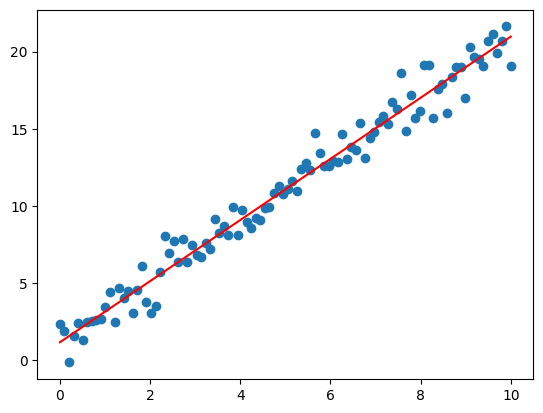

W1: 
 [[-0.01  1.06 -0.01  0.2  -0.   -0.   -0.    0.05  0.18  0.87]]

W2: 
 [[ 0.02]
 [ 1.08]
 [ 0.  ]
 [ 0.2 ]
 [-0.02]
 [-0.01]
 [-0.  ]
 [ 0.05]
 [ 0.19]
 [ 0.89]]


In [33]:
input_size = 1
output_size = 1
hidden_size = 10
lr = 0.001
epochs = 1000
lambda_reg = 0.01

W1 = np.random.randn(input_size, hidden_size) * 0.01
W2 = np.random.randn(hidden_size, input_size) * 0.01
b1 = np.zeros((1, hidden_size))
b2 = np.zeros((1, output_size))

n = len(X)
losses = []
for epoch in range(epochs):
    z1 = X @ W1 + b1
    a1 = np.maximum(0, z1)
    
    z2 = a1 @ W2 + b2
    y_p = z2
    
    dL_dyp = 2 / n * (y_p - y)
    dL_dW2 = a1.T @ dL_dyp + 2 * lambda_reg * W2
    # dL_db2 = dL_dyp.copy()
    # dL_db2 = np.sum(dL_dyp)
    dL_db2 = np.sum(dL_dyp, axis=0, keepdims=True)
    
    dL_da1 = dL_dyp @ W2.T
    dL_dz1 = dL_da1.copy()
    dL_dz1[z1 <= 0] = 0
    
    dL_dW1 = X.T @ dL_dz1 + 2 * lambda_reg * W1
    # dL_db1 = dL_dz1.copy()
    dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)
    
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1
    
    loss = np.mean((y_p - y) ** 2)
    loss += lambda_reg * (np.sum(W1**2) + np.sum(W2 ** 2))
    losses.append(loss)
    if epoch % 100 == 0:
        
        print(f'epoch {epoch} loss: {loss}')
        
        
plt.plot(losses)
plt.show()


plt.scatter(X, y)
plt.plot(X, y_p, color='red')
plt.show()

print('W1: \n', np.round(W1, 2))
print('\nW2: \n', np.round(W2, 2))


epoch 0 loss: 156.8586471583656
epoch 100 loss: 0.9844081821141085
epoch 200 loss: 0.9858900014968174
epoch 300 loss: 0.9872579132648198
epoch 400 loss: 0.9884948959593393
epoch 500 loss: 0.9895908780434246
epoch 600 loss: 0.9905427804324918
epoch 700 loss: 0.9913484661090066
epoch 800 loss: 0.9920067411433322
epoch 900 loss: 0.992514939678365


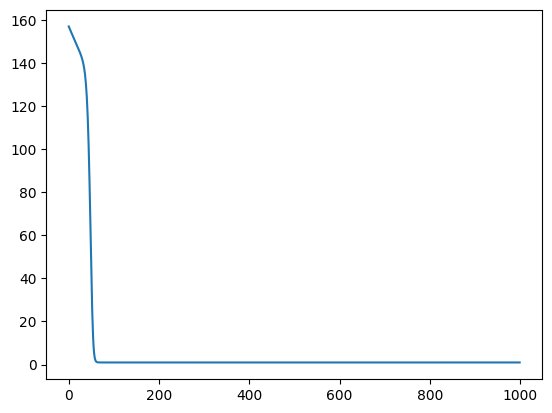

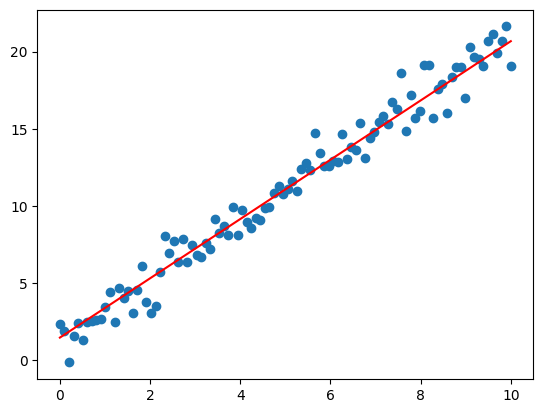

W1: 
 [[ 0.   -0.   -0.    0.    0.    0.76 -0.    1.15 -0.    0.  ]]

W2: 
 [[-0.  ]
 [ 0.  ]
 [ 0.  ]
 [-0.  ]
 [-0.  ]
 [ 0.77]
 [ 0.  ]
 [ 1.16]
 [ 0.  ]
 [ 0.  ]]


In [34]:
input_size = 1
output_size = 1
hidden_size = 10
lr = 0.001
epochs = 1000
lambda_reg = 0.01

W1 = np.random.randn(input_size, hidden_size) * 0.01
W2 = np.random.randn(hidden_size, input_size) * 0.01
b1 = np.zeros((1, hidden_size))
b2 = np.zeros((1, output_size))

n = len(X)
losses = []
for epoch in range(epochs):
    z1 = X @ W1 + b1
    a1 = np.maximum(0, z1)
    
    z2 = a1 @ W2 + b2
    y_p = z2
    
    dL_dyp = 2 / n * (y_p - y)
    dL_dW2 = a1.T @ dL_dyp + np.sign(W2)
    # dL_db2 = dL_dyp.copy()
    # dL_db2 = np.sum(dL_dyp)
    dL_db2 = np.sum(dL_dyp, axis=0, keepdims=True)
    
    dL_da1 = dL_dyp @ W2.T
    dL_dz1 = dL_da1.copy()
    dL_dz1[z1 <= 0] = 0
    
    dL_dW1 = X.T @ dL_dz1 + np.sign(W1)
    # dL_db1 = dL_dz1.copy()
    dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)
    
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1
    
    loss = np.mean((y_p - y) ** 2)
    loss += lambda_reg * (np.sum(np.abs(W1)) + np.sum(np.abs(W2)))
    losses.append(loss)
    if epoch % 100 == 0:
        
        print(f'epoch {epoch} loss: {loss}')
        
        
plt.plot(losses)
plt.show()


plt.scatter(X, y)
plt.plot(X, y_p, color='red')
plt.show()

print('W1: \n', np.round(W1, 2))
print('\nW2: \n', np.round(W2, 2))